In [154]:
import torch 
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
import torchvision.models as tmodels
import torch.nn as nn
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

['Bus', 'Car', 'Truck', 'motorcycle']
{'Bus': 0, 'Car': 1, 'Truck': 2, 'motorcycle': 3} 0


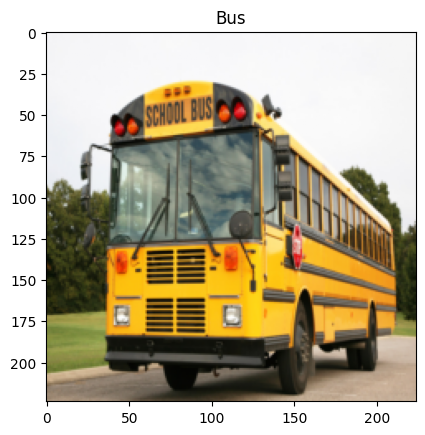

In [157]:
# dataset link = https://www.kaggle.com/datasets/kaggleashwin/vehicle-type-recognition
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomCrop((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

base_data = datasets.ImageFolder(root='data')
class_names = base_data.classes

generator = torch.Generator().manual_seed(42)
train_size = int(0.7 * len(base_data))
val_size = int(0.15 * len(base_data))
test_size = len(base_data) - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    base_data,
    [train_size, val_size, test_size],
    generator=generator
)

train_dataset = datasets.ImageFolder(root='data', transform=transform)
eval_dataset = datasets.ImageFolder(root='data', transform=transform_test)

train_data = Subset(train_dataset, train_subset.indices)
val_data = Subset(eval_dataset, val_subset.indices)
test_data = Subset(eval_dataset, test_subset.indices)

sample_image, sample_label = eval_dataset[0]
print(class_names)
print(base_data.class_to_idx, sample_label)

plt.imshow(sample_image.permute(1,2,0))
plt.title(class_names[sample_label])
plt.show()

In [159]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = tmodels.resnet18(weights= tmodels.ResNet18_Weights.DEFAULT)
for i in model.parameters():
    i.requires_grad = False
    
model.fc = nn.Linear(model.fc.in_features, out_features=4)

for param in model.fc.parameters():
    param.requires_grad = True

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

model = model.to(device)
# model

# for name, param in model.named_parameters():
#     print(name, param.requires_grad)
  

In [160]:

def evaluate(loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_targets.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = running_loss / len(loader)
    acc = correct / total * 100
    return avg_loss, acc, np.array(all_targets), np.array(all_preds)


for epoch in range(10):
    model.train()
    losses = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        output =  model(images)
        
        optimizer.zero_grad()   
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()
        
        losses += loss.item()
        
    val_loss, val_acc, _, _ = evaluate(val_loader)
    print(
        f"Epoch {epoch+1}, "
        f"Train Loss: {losses / len(train_loader):.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.2f}%"
    )

        

c:\Users\ASUS\PycharmProjects\Machine-learning\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1, Train Loss: 1.3101, Val Loss: 1.0823, Val Acc: 63.33%
Epoch 2, Train Loss: 1.0408, Val Loss: 0.8362, Val Acc: 76.67%
Epoch 3, Train Loss: 0.7512, Val Loss: 0.6512, Val Acc: 88.33%
Epoch 4, Train Loss: 0.6358, Val Loss: 0.5258, Val Acc: 90.00%
Epoch 5, Train Loss: 0.5036, Val Loss: 0.4574, Val Acc: 90.00%
Epoch 6, Train Loss: 0.4313, Val Loss: 0.3985, Val Acc: 91.67%
Epoch 7, Train Loss: 0.4079, Val Loss: 0.3488, Val Acc: 95.00%
Epoch 8, Train Loss: 0.3499, Val Loss: 0.3203, Val Acc: 95.00%
Epoch 9, Train Loss: 0.3479, Val Loss: 0.2968, Val Acc: 95.00%
Epoch 10, Train Loss: 0.2876, Val Loss: 0.3082, Val Acc: 93.33%


Validation Accuracy: 93.33%
Test Accuracy: 90.00%


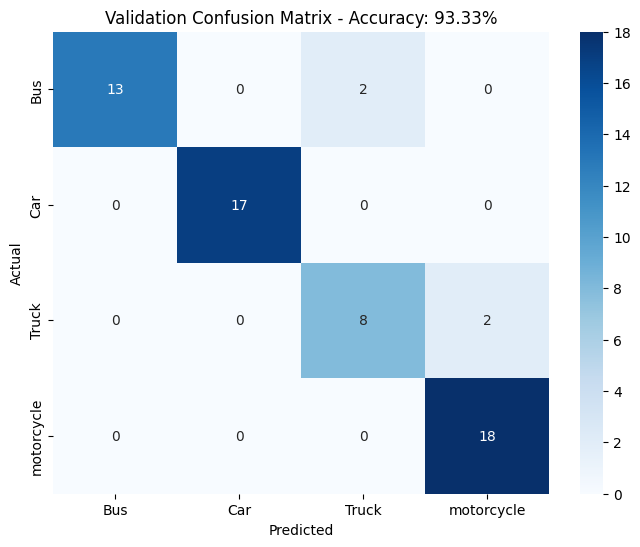

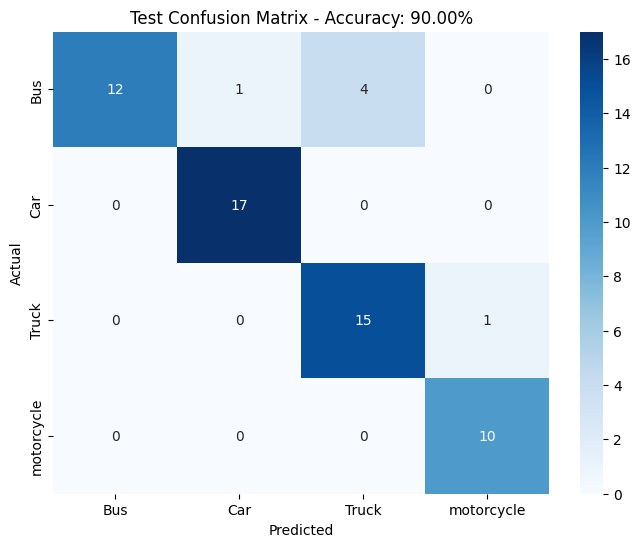

In [161]:
def plot_confusion_matrix(loader, title):
    _, acc, y_true, y_pred = evaluate(loader)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{title} - Accuracy: {acc:.2f}%')
    plt.show()


val_loss, val_acc, _, _ = evaluate(val_loader)
test_loss, test_acc, _, _ = evaluate(test_loader)

print(f"Validation Accuracy: {val_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

plot_confusion_matrix(val_loader, 'Validation Confusion Matrix')
plot_confusion_matrix(test_loader, 'Test Confusion Matrix')


In [166]:
torch.save(
    model.state_dict(),
    "vehicle_classifier.pth"
)

In [165]:
from PIL import Image

img = Image.open("unseendata/car2.jpeg").convert("RGB")
img = transform_test(img)
img = img.unsqueeze(0)
img.shape
img = img.to(device)
model.eval()

with torch.no_grad():
    out = model(img)

pred = torch.argmax(out, dim=1)
class_names[pred.item()]


'Truck'